# Stop/Save Behavioral Profiling — EDA v2

This notebook profiles mature monthly subscribers who contacted after receiving a price-increase notice. It complements the completed treatment/CNRC evaluation; it does not re-estimate treatment performance.

The v2 workflow replaces exhaustive segment boxplots with:

1. One overall Saved-versus-Stopped distribution comparison.
2. An absolute behavior-profile heatmap using a common contacted-population reference.
3. A matched Saved-minus-Stopped contrast heatmap.
4. Detailed boxplots for only the strongest adequately supported contrasts.

Treatment is deliberately excluded from the primary profile definition because it is an experimental assignment rather than a user characteristic. It remains available for targeted follow-up after a behavioral segment is identified.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from google.cloud import bigquery

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.eda_helpers import (
    build_distribution_summary,
    cast_numeric_fields,
    plot_metric_boxplot_views,
)
from src.eda_helpers_v2 import (
    ID_COL,
    OUTCOME_COL,
    OUTCOMES,
    build_behavior_profiles,
    build_outcome_contrasts,
    build_selected_segment_detail_table,
    fit_behavior_reference,
    plot_behavior_profile_heatmap,
    plot_outcome_contrast_heatmap,
    plot_selected_segment_clipped_boxplot_grid,
    plot_top_behavior_contrasts,
)

CHART_DIR = PROJECT_ROOT / "src" / "notebooks" / "charts" / "behavior_v2"
TABLE_DIR = PROJECT_ROOT / "src" / "notebooks" / "tables" / "behavior_v2"

In [3]:
PROJECT_ID = "gannett-datascience"
TABLE_ID = "gannett-datascience.test_results_zone.ss_test_result_v3-2"

NUMERIC_FIELDS = [
    "frequency",
    "breadth",
    "tenure",
    "tt_cost",
]
BASE_SEGMENT_FIELDS = [
    "contact_channel_group",
    "contact_timing",
    "cohort",
    "src_risk_tier",
    "repeated_call_group",
]
PROFILE_FIELDS = [OUTCOME_COL, *BASE_SEGMENT_FIELDS]
MIN_PROFILE_USERS = 20
TOP_CONTRASTS = 8
BOOTSTRAP_ITERATIONS = 2_000  # Set to 0 to skip confidence intervals.
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

## 1. Load the matured contacted population

The source table already excludes conflicting permanent-stop versus channel-event classifications. Users who did not contact are outside this profiling population.

In [4]:
query_fields = [
    ID_COL,
    "id_subscrip",
    "email_date",
    "status",
    "Treatment",
    "contact_channel",
    "contact_timing",
    "cohort",
    "repeatedly_called",
    "src_risk_tier",
    *NUMERIC_FIELDS,
]
query = f"""
SELECT
  {', '.join(query_fields)}
FROM `{TABLE_ID}`
WHERE email_date < '2026-05-01'
  AND status IN ('saved', 'stoped')
"""

client = bigquery.Client(project=PROJECT_ID)
df_action = client.query(query).to_dataframe()
df_action = cast_numeric_fields(df_action, NUMERIC_FIELDS)
df_action["contact_channel_group"] = df_action["contact_channel"].replace(
    {
        "Online first": "Contacted both ways",
        "Called-In first": "Contacted both ways",
    }
)
df_action["repeated_call_group"] = np.where(
    df_action["repeatedly_called"].fillna(0).astype(int).eq(1),
    "Repeatedly Called",
    "Called Once"
)
df_action[OUTCOME_COL] = df_action["status"].replace(
    {"saved": "Saved", "stoped": "Stopped"}
)
risk_tier = df_action["src_risk_tier"].astype("string")
df_action["src_risk_tier"] = risk_tier.where(
    risk_tier.isna() | risk_tier.str.endswith(" risk"),
    risk_tier + " risk",
)

if df_action.empty:
    raise ValueError("EDA v2 requires at least one contacted account.")
if df_action[ID_COL].isna().any():
    raise ValueError(f"{ID_COL} must not contain missing values.")
if df_action[ID_COL].duplicated().any():
    raise ValueError("EDA v2 requires one row per contacted billing account.")
empty_metrics = [
    metric for metric in NUMERIC_FIELDS
    if df_action[metric].notna().sum() == 0
]
if empty_metrics:
    raise ValueError(f"Metrics contain no observations: {empty_metrics}")

/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [5]:
population_check = (
    df_action.groupby(OUTCOME_COL, observed=True)[ID_COL]
    .nunique()
    .reindex(OUTCOMES)
    .rename("accounts")
    .reset_index()
)
display(population_check)

,outcome,accounts
0,Saved,589
1,Stopped,942


## 2. Overall behavioral baseline

This is the only broad distribution chart. Because Saved and Stopped are plotted together, their clipped and standardized values use one common contacted-population reference.

In [6]:
overall_distribution_summary = pd.concat(
    {
        outcome: build_distribution_summary(
            df_action[df_action[OUTCOME_COL].eq(outcome)],
            NUMERIC_FIELDS,
        )
        for outcome in OUTCOMES
    },
    names=[OUTCOME_COL],
).reset_index(level=0).reset_index(drop=True)
display(overall_distribution_summary)

,outcome,field,row_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median,std,p01,p05,p10,p25,p50,p75,p90,p95,p99
0,Saved,frequency,589,2,0.34,28,0,0.00,91.00,56.41,67.00,32.41,0.00,1.00,5.60,26.00,67.00,88.00,91.00,91.00,91.00
1,Saved,breadth,589,2,0.34,64,0,0.00,18.00,5.69,5.00,4.06,0.00,0.00,0.00,2.00,5.00,9.00,11.00,13.00,16.00
2,Saved,tenure,589,2,0.34,0,0,323.00,"10,500.00","1,542.57","1,454.00",832.41,324.86,346.00,724.00,"1,148.00","1,454.00","1,777.50","2,416.40","2,704.80","3,722.36"
3,Saved,tt_cost,589,2,0.34,0,0,36.46,"3,496.50",468.53,428.24,309.50,107.85,114.09,163.43,268.02,428.24,572.52,788.32,949.16,"1,680.29"
4,Stopped,frequency,942,1,0.11,155,0,0.00,91.00,39.35,33.00,34.21,0.00,0.00,0.00,4.00,33.00,76.00,89.00,91.00,91.00
5,Stopped,breadth,942,1,0.11,228,0,0.00,20.00,4.64,4.00,4.22,0.00,0.00,0.00,1.00,4.00,8.00,11.00,13.00,15.00
6,Stopped,tenure,942,1,0.11,0,0,324.00,"11,789.00","1,476.51","1,421.00",812.18,329.80,390.00,510.00,"1,142.00","1,421.00","1,696.00","2,245.00","2,588.00","3,752.00"
7,Stopped,tt_cost,942,1,0.11,0,0,25.91,"3,925.74",526.75,483.85,351.18,109.82,154.86,169.50,311.02,483.85,645.02,839.16,"1,050.46","1,824.59"


In [7]:
_ = plot_metric_boxplot_views(
    data=df_action,
    metrics=NUMERIC_FIELDS,
    group_col=OUTCOME_COL,
    group_order=list(OUTCOMES),
    chart_title="Behavior metrics: Saved vs Stopped | EDA v2",
    chart_folder=str(CHART_DIR),
    file_name="overall_saved_vs_stopped_v2.png",
)

## 3. Fit one contacted-population reference

Every downstream score clips at the contacted population's 1st–99th percentiles, subtracts its median, and divides by its IQR. A score of `+1` means the segment median is one contacted-population IQR above typical.

In [8]:
behavior_reference = fit_behavior_reference(df_action, NUMERIC_FIELDS)
reference_summary = pd.DataFrame(
    {
        "p01": behavior_reference["lower_bounds"],
        "median": behavior_reference["centers"],
        "iqr": behavior_reference["spreads"],
        "p99": behavior_reference["upper_bounds"],
    }
)
display(reference_summary)

,p01,median,iqr,p99
frequency,0.00,46.00,73.00,91.00
breadth,0.00,4.00,7.00,15.73
tenure,325.27,"1,450.00",584.25,"3,790.92"
tt_cost,108.23,462.87,331.85,"1,788.55"


## 4. Absolute segment profiles

Rows are ordered by multivariate distance from the typical contacted account. Only outcome-specific segments with at least `MIN_PROFILE_USERS` unique accounts are included.

In [9]:
behavior_profiles = build_behavior_profiles(
    df_action,
    metrics=NUMERIC_FIELDS,
    segment_fields=PROFILE_FIELDS,
    min_n=MIN_PROFILE_USERS,
    reference=behavior_reference,
)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
behavior_profiles_path = TABLE_DIR / "behavior_profiles_v2.csv"
behavior_profiles.to_csv(behavior_profiles_path, index=False)
display(behavior_profiles)

,outcome,contact_channel_group,contact_timing,cohort,src_risk_tier,repeated_call_group,segment_label,users,median__frequency,median__breadth,median__tenure,median__tt_cost,score__frequency,score__breadth,score__tenure,score__tt_cost,profile_magnitude,dominant_metric
0,Stopped,Online Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,Stopped · Online Cancel Flow · Contact On/Afte...,55,2.00,0.00,"1,180.00",372.29,-0.60,-0.57,-0.46,-0.27,0.99,frequency
1,Stopped,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,Stopped · Called-In Cancel Flow · Contact On/A...,28,22.00,4.00,"1,832.00",662.34,-0.33,0.00,0.65,0.60,0.95,tenure
2,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,Stopped · Called-In Cancel Flow · Contact Befo...,37,34.00,4.00,"1,815.00",656.01,-0.16,0.00,0.62,0.58,0.87,tenure
3,Stopped,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,3. Medium risk,Called Once,Stopped · Called-In Cancel Flow · Contact On/A...,27,1.00,0.00,"1,363.00",502.16,-0.62,-0.57,-0.15,0.12,0.86,frequency
4,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,3. Medium risk,Called Once,Stopped · Called-In Cancel Flow · Contact Befo...,37,2.00,0.00,"1,391.00",494.17,-0.60,-0.57,-0.10,0.09,0.84,frequency
5,Stopped,Online Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Called Once,Stopped · Online Cancel Flow · Contact On/Afte...,34,82.50,7.00,"1,709.50",536.30,0.50,0.43,0.44,0.22,0.82,frequency
6,Saved,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Called Once,Saved · Called-In Cancel Flow · Contact On/Aft...,78,87.50,7.00,"1,526.00",447.24,0.57,0.43,0.13,-0.05,0.73,frequency
7,Stopped,Online Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,Stopped · Online Cancel Flow · Contact Before ...,49,37.00,5.00,"1,697.00",635.70,-0.12,0.14,0.42,0.52,0.70,tt_cost
8,Stopped,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Called Once,Stopped · Called-In Cancel Flow · Contact Befo...,117,82.00,7.00,"1,544.00",474.19,0.49,0.43,0.16,0.03,0.67,frequency
9,Saved,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Called Once,Saved · Called-In Cancel Flow · Contact Before...,124,83.50,6.00,"1,567.00",382.28,0.51,0.29,0.20,-0.24,0.67,frequency


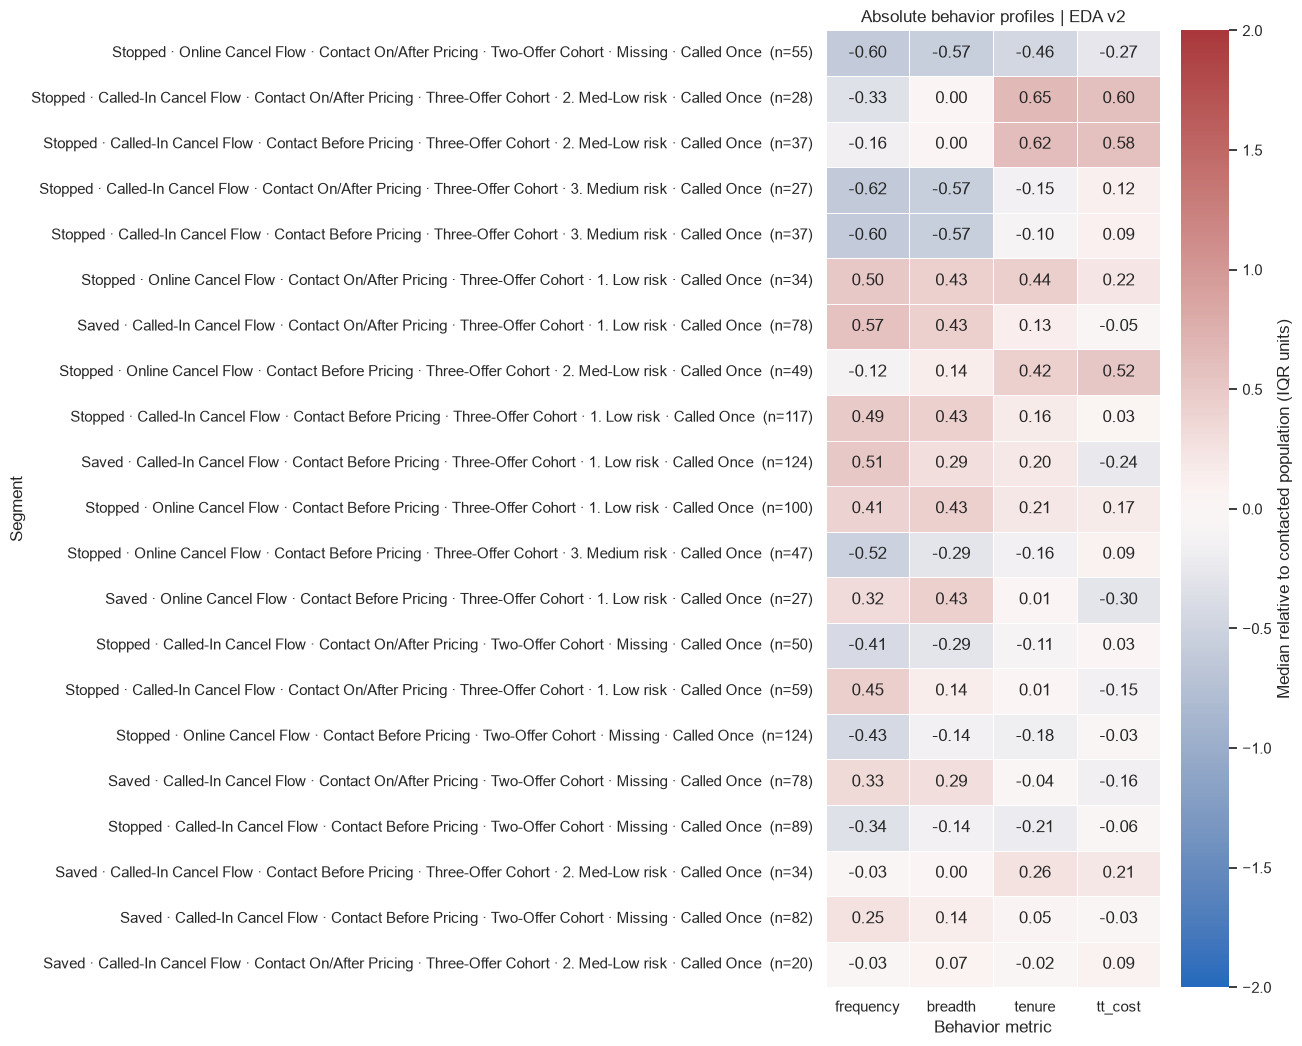

In [10]:
_ = plot_behavior_profile_heatmap(
    behavior_profiles,
    metrics=NUMERIC_FIELDS,
    color_limit=2.0,
    title="Absolute behavior profiles | EDA v2",
    chart_folder=str(CHART_DIR),
    file_name="absolute_behavior_profiles_v2.png",
    show=True,
    close=True,
)

## 5. Matched Saved-minus-Stopped contrasts

Each row compares Saved with Stopped users inside the same channel × timing × cohort × risk slice. Positive cells mean the Saved median is higher; negative cells mean the Stopped median is higher. Both outcomes must independently meet `MIN_PROFILE_USERS`.

In [11]:
outcome_contrasts = build_outcome_contrasts(
    df_action,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    min_n=MIN_PROFILE_USERS,
    reference=behavior_reference,
)
outcome_contrasts_path = TABLE_DIR / "saved_minus_stopped_contrasts_v2.csv"
outcome_contrasts.to_csv(outcome_contrasts_path, index=False)
display(outcome_contrasts)

,contact_channel_group,contact_timing,cohort,src_risk_tier,repeated_call_group,segment_label,n__saved,n__stopped,median_saved__frequency,median_saved__breadth,median_saved__tenure,median_saved__tt_cost,median_stopped__frequency,median_stopped__breadth,median_stopped__tenure,median_stopped__tt_cost,delta__frequency,delta__breadth,delta__tenure,delta__tt_cost,total_users,observed_saved_share,contrast_magnitude,dominant_metric,dominant_outcome
0,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,Called-In Cancel Flow · Contact On/After Prici...,78,50,70.00,6.00,"1,425.00",408.26,16.00,2.00,"1,388.00",472.53,0.74,0.57,0.06,-0.19,128,0.61,0.96,frequency,Saved
1,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,Called-In Cancel Flow · Contact On/After Prici...,20,28,43.50,4.50,"1,438.50",493.34,22.00,4.00,"1,832.00",662.34,0.29,0.07,-0.67,-0.51,48,0.42,0.90,tenure,Stopped
2,Called-In Cancel Flow,Contact Before Pricing,Two-Offer Cohort,<NA>,Called Once,Called-In Cancel Flow · Contact Before Pricing...,82,89,64.50,5.00,"1,478.00",453.71,21.00,3.00,"1,328.00",443.56,0.60,0.29,0.26,0.03,171,0.48,0.71,frequency,Saved
3,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,Called-In Cancel Flow · Contact Before Pricing...,34,37,44.00,4.00,"1,602.50",533.63,34.00,4.00,"1,815.00",656.01,0.14,0.00,-0.36,-0.37,71,0.48,0.54,tt_cost,Stopped
4,Online Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Called Once,Online Cancel Flow · Contact Before Pricing · ...,27,100,69.00,7.00,"1,454.00",364.64,76.00,7.00,"1,573.50",519.89,-0.10,0.00,-0.20,-0.47,127,0.21,0.52,tt_cost,Stopped
5,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,1. Low risk,Called Once,Called-In Cancel Flow · Contact On/After Prici...,78,59,87.50,7.00,"1,526.00",447.24,79.00,5.00,"1,453.00",411.59,0.12,0.29,0.12,0.11,137,0.57,0.35,breadth,Saved
6,Called-In Cancel Flow,Contact Before Pricing,Three-Offer Cohort,1. Low risk,Called Once,Called-In Cancel Flow · Contact Before Pricing...,124,117,83.50,6.00,"1,567.00",382.28,82.00,7.00,"1,544.00",474.19,0.02,-0.14,0.04,-0.28,241,0.51,0.31,tt_cost,Stopped


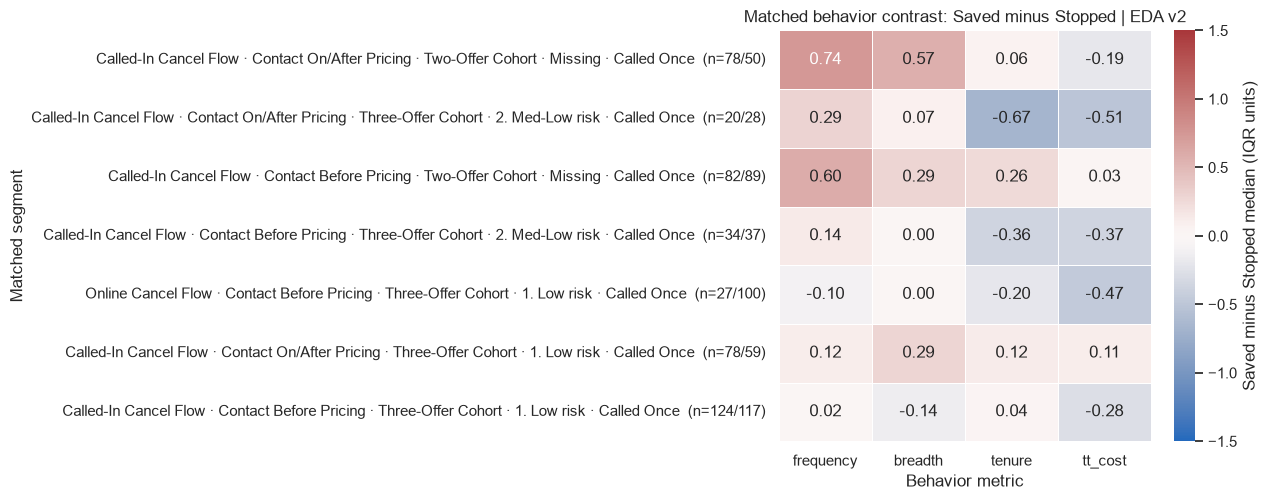

In [12]:
_ = plot_outcome_contrast_heatmap(
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    color_limit=1.5,
    title="Matched behavior contrast: Saved minus Stopped | EDA v2",
    chart_folder=str(CHART_DIR),
    file_name="saved_minus_stopped_heatmap_v2.png",
    show=True,
    close=True,
)

## 6. Distribution drill-down for the strongest contrasts

The detailed boxplots are deliberately limited to the largest adequately supported multivariate contrasts. All panels share the same contacted-population scale.

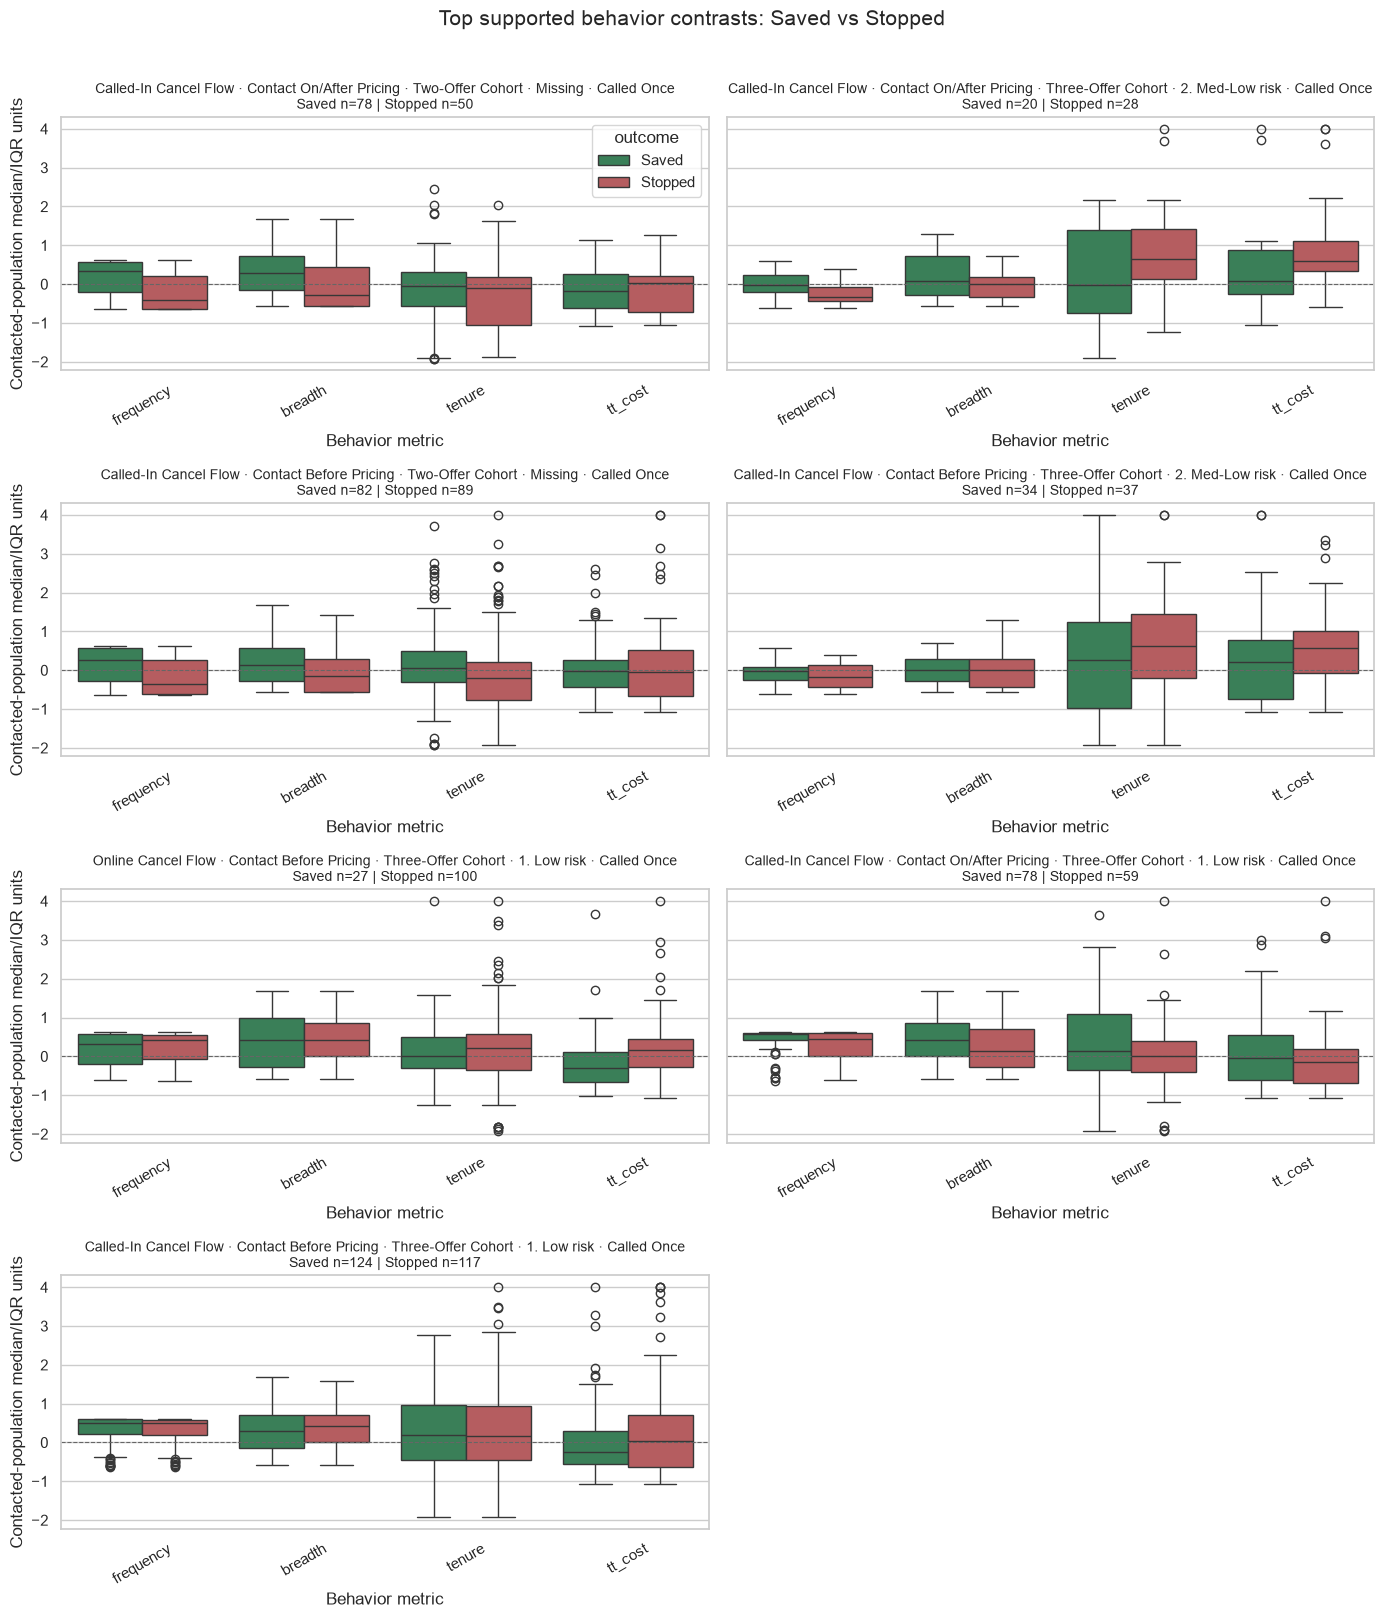

In [13]:
_ = plot_top_behavior_contrasts(
    df_action,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    chart_folder=str(CHART_DIR),
    file_name="top_behavior_contrasts_v2.png",
    show=True,
    close=True,
)

## 7. Selected-segment business magnitude and uncertainty

This section adds only the information not already provided by the standardized contrast workflow:

- **Raw clipped boxplots** translate the selected contrasts into each metric's business units. Each metric column has one shared y-axis across all selected segments.
- **One compact detail table** carries forward the existing Saved/Stopped counts and medians, then adds clipped quartiles, IQRs, non-null counts, and optional bootstrap intervals for the clipped median difference.

Set `BOOTSTRAP_ITERATIONS = 0` to skip confidence intervals. The intervals are descriptive and are not multiple-comparison-adjusted hypothesis tests.

In [14]:
selected_business_summary = build_selected_segment_detail_table(
    df_action,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
    confidence_level=BOOTSTRAP_CONFIDENCE_LEVEL,
    random_state=42,
)
selected_business_summary.to_csv(
    TABLE_DIR / "selected_segment_business_summary_v2.csv",
    index=False,
)
display(selected_business_summary)

,segment_rank,segment_label,contact_channel_group,contact_timing,cohort,src_risk_tier,repeated_call_group,metric,n__saved,non_null__saved,clipped_median__saved,clipped_q25__saved,clipped_q75__saved,clipped_iqr__saved,n__stopped,non_null__stopped,clipped_median__stopped,clipped_q25__stopped,clipped_q75__stopped,clipped_iqr__stopped,clipped_median_difference,clipped_median_difference_ci_lower,clipped_median_difference_ci_upper,bootstrap_iterations,confidence_level
0,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,frequency,78,77,70.00,31.00,88.00,57.00,50,49,16.00,0.00,62.00,62.00,54.00,33.00,74.00,2000,0.95
1,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,breadth,78,77,6.00,3.00,9.00,6.00,50,49,2.00,0.00,7.00,7.00,4.00,1.00,6.00,2000,0.95
2,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,tenure,78,77,"1,425.00","1,118.00","1,636.00",518.00,50,49,"1,388.00",841.00,"1,556.00",715.00,37.00,-90.00,384.00,2000,0.95
3,1,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Two-Offer Cohort,<NA>,Called Once,tt_cost,78,77,408.26,256.21,551.45,295.24,50,49,472.53,221.06,530.47,309.41,-64.27,-117.39,122.21,2000,0.95
4,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,frequency,20,20,43.50,31.50,62.75,31.25,28,28,22.00,14.00,39.75,25.75,21.50,8.50,40.00,2000,0.95
5,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,breadth,20,20,4.50,2.00,9.00,7.00,28,28,4.00,1.75,5.25,3.50,0.50,-2.00,5.00,2000,0.95
6,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,tenure,20,20,"1,438.50","1,018.25","2,272.00","1,253.75",28,28,"1,832.00","1,534.50","2,277.50",743.00,-393.50,-845.00,288.00,2000,0.95
7,2,Called-In Cancel Flow · Contact On/After Prici...,Called-In Cancel Flow,Contact On/After Pricing,Three-Offer Cohort,2. Med-Low risk,Called Once,tt_cost,20,20,493.34,378.07,756.58,378.50,28,28,662.34,574.01,832.00,257.99,-169.00,-325.35,99.25,2000,0.95
8,3,Called-In Cancel Flow · Contact Before Pricing...,Called-In Cancel Flow,Contact Before Pricing,Two-Offer Cohort,<NA>,Called Once,frequency,82,82,64.50,26.25,87.75,61.50,89,89,21.00,2.00,66.00,64.00,43.50,21.00,60.00,2000,0.95
9,3,Called-In Cancel Flow · Contact Before Pricing...,Called-In Cancel Flow,Contact Before Pricing,Two-Offer Cohort,<NA>,Called Once,breadth,82,82,5.00,2.00,8.00,6.00,89,89,3.00,0.00,6.00,6.00,2.00,0.00,4.50,2000,0.95


### Raw clipped values: business magnitude

Compare Saved and Stopped users within a row, then compare the same metric vertically across rows. Because metrics retain their own units, do not compare box heights across different columns. Counts are reused from `outcome_contrasts` and included in the x-axis labels.

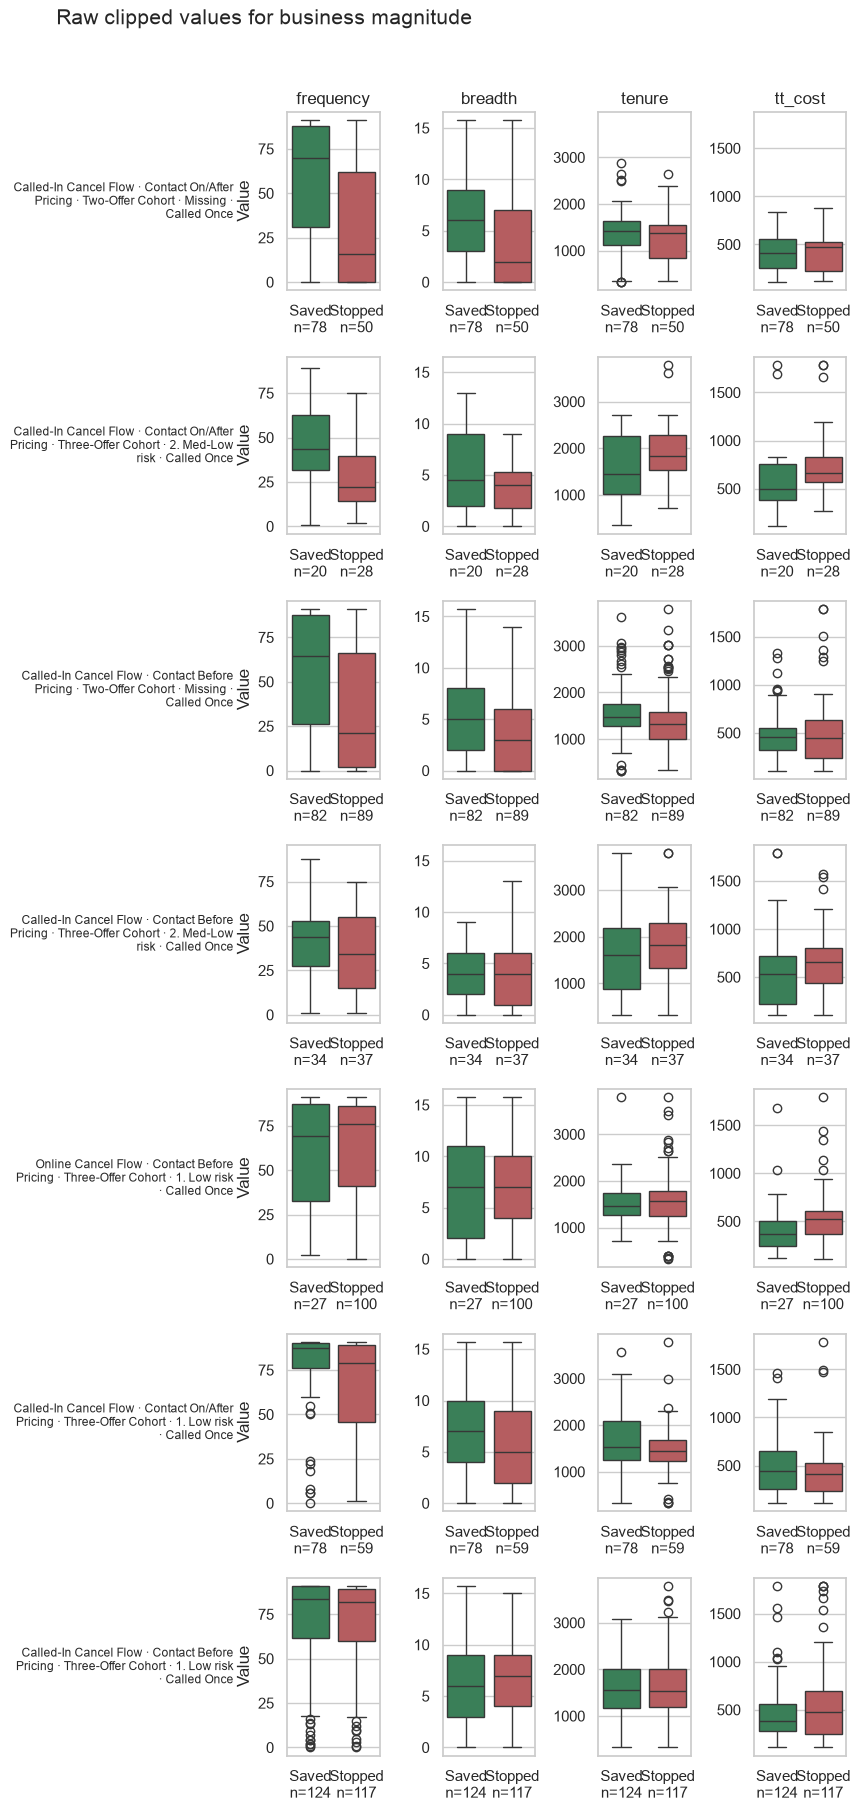

In [15]:
_ = plot_selected_segment_clipped_boxplot_grid(
    df_action,
    outcome_contrasts,
    metrics=NUMERIC_FIELDS,
    segment_fields=BASE_SEGMENT_FIELDS,
    reference=behavior_reference,
    top_n=TOP_CONTRASTS,
    chart_folder=str(CHART_DIR),
    file_name="selected_segments_raw_clipped_v2.png",
    show=True,
    close=True,
)

## Interpretation guide

A useful behavioral profile should combine multiple aligned signals rather than one small median difference. Examples include:

- High frequency + high breadth: strongly engaged.
- Long tenure + low frequency/breadth: established but disengaging.
- Low engagement + high `tt_cost`: possible weak value perception, subject to the business definition of `tt_cost`.
- High engagement + high `tt_cost`: engaged but potentially price-sensitive.

Review order:

1. Use the absolute heatmap to find behaviorally unusual segments.
2. Use the contrast heatmap to determine whether Saved and Stopped users differ inside the same segment.
3. Use the Section 6 standardized boxplots to verify overlap and skew on the common comparison scale.
4. Use the raw clipped grid to translate those selected contrasts into business units.
5. Confirm clipped medians, IQRs, non-null counts, and uncertainty in the selected-segment table. Treat wide bootstrap intervals as a warning that an apparent contrast may be unstable.

These are descriptive profiles, not treatment-effect estimates or formal customer clusters. Treatment can be added as a targeted drill-down after a stable behavioral contrast is found.